In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
def exact_solution(x, t, eps):
    return -np.tanh((x + 0.5 - t)/(2*eps)) + 1

def eta(x, eps):
    return exact_solution(x, 0, eps)

def gL(t, eps):
    return exact_solution(-1, t, eps)

def gR(t, eps):
    return exact_solution(1, t, eps)


def Burgers_FTBS_FTCS(eps, T, Nx, cfl_adv=0.8, cfl_diff=0.8):

    xmin, xmax = -1.0, 1.0
    dx = (xmax - xmin)/Nx
    x = np.linspace(xmin, xmax, Nx+1)

    u = eta(x, eps)

    t = 0.0

    while t < T:

        u_max = np.max(np.abs(u))
        dt_adv = dx / max(u_max, 1e-12)
        dt_diff = 0.5 *dx**2 / eps

        dt = min(cfl_adv * dt_adv, cfl_diff * dt_diff, T - t)

        u_new = u.copy()

        a = dt / dx
        d = eps * dt / dx**2

        u_new[1:-1] = (
            u[1:-1]
            - a * u[1:-1] * (u[1:-1] - u[:-2])
            + d * (u[2:] - 2*u[1:-1] + u[:-2])
        )

        t += dt

        u_new[0]  = gL(t, eps)
        u_new[-1] = gR(t, eps)

        u = u_new

    return x, u

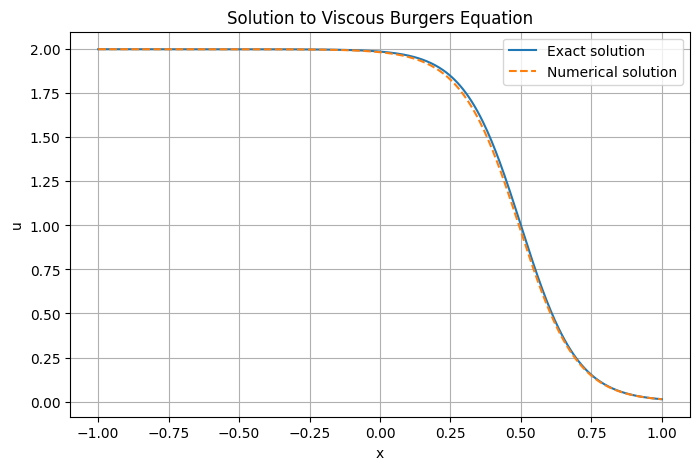

In [125]:
# Parameters
eps = 0.1
T = 1
Nx = 400


x, u = Burgers_FTBS_FTCS(eps, T, Nx)

u_exact = exact_solution(x, T, eps)

# Plot
plt.figure(figsize=(8,5))

plt.plot(x, u_exact, label="Exact solution")
plt.plot(x, u, "--", label="Numerical solution")


plt.xlabel("x")
plt.ylabel("u")
plt.title(f"Solution to Viscous Burgers Equation")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
import numpy as np

Nx_values = [100, 200, 400, 800,1600]

dx_errors = []
dx_values = []

eps = 0.1
T = 1.0

for Nx in Nx_values:

    x, u = Burgers_FTBS_FTCS(eps, T, Nx)

    dx = x[1] - x[0]

    # exact solution at final time
    u_ex = exact_solution(x, T, eps)

    # L-infinity error
    error = np.max(np.abs(u - u_ex))

    dx_errors.append(error)
    dx_values.append(dx)

dx_values = np.array(dx_values)
dx_errors = np.array(dx_errors)

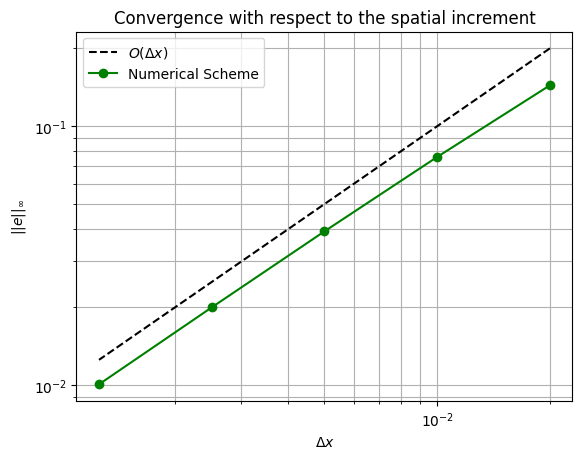

array([0.98783086, 2.0032991 ])

In [91]:
plt.loglog(dx_values,10*np.array(dx_values), 'k--', label=r"$O(\Delta x)$")
plt.loglog(dx_values,dx_errors,'o-',color="green", label=r"Numerical Scheme")
plt.title("Convergence with respect to the spatial increment")
plt.xlabel(r'$\Delta x$')
plt.ylabel(r'$||e||_\infty$')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

np.polyfit(np.log(dx_values[3:]),np.log(dx_errors[3:]),1)

# New IBVP

In [43]:
def eta(x, eps):
    return -np.sin(np.pi * x)

def gL(t, eps):
    return 0.0

def gR(t, eps):
    return 0.0


# Parameters
eps = 0.01 / np.pi
T = 1.6037 / np.pi
Nx = 2000

x, u = Burgers_FTBS_FTCS(eps, T, Nx,cfl_adv=0.4,cfl_diff=0.2)
dx = x[1] - x[0]

# find index closest to x = 0
j0 = np.argmin(np.abs(x))

# numerical derivative at x=0
ux0 = (u[j0 + 1] - u[j0 - 1]) / (2 * dx)
ux1 = (
    -u[j0 + 2]
    + 8*u[j0 + 1]
    - 8*u[j0 - 1]
    + u[j0 - 2]
) / (12 * dx)
print("Approx ∂x u(0,t):", ux0)
print("Approx ∂x u(0,t):", ux1)

Approx ∂x u(0,t): -47.99860275141644
Approx ∂x u(0,t): -47.52563733191766


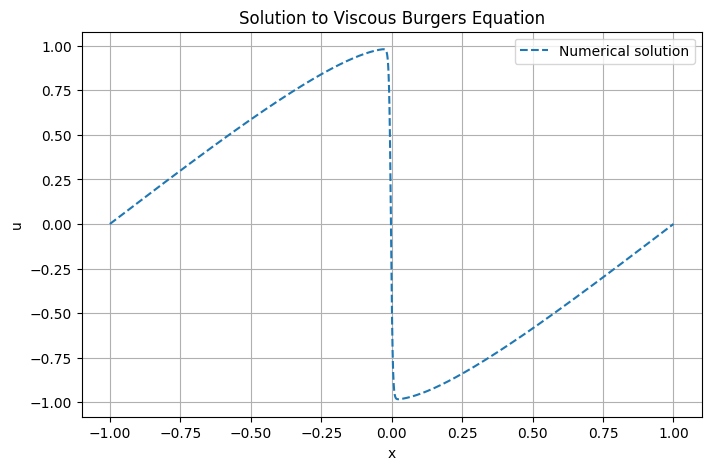

In [4]:
# Plot
plt.figure(figsize=(8,5))

plt.plot(x, u, "--", label="Numerical solution")


plt.xlabel("x")
plt.ylabel("u")
plt.title(f"Solution to Viscous Burgers Equation")

plt.grid(True)
plt.legend()

plt.show()

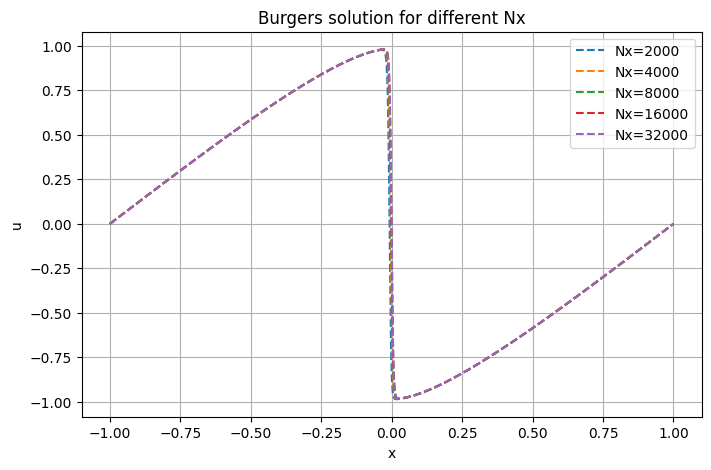

In [84]:
# reference value
ux_ref = -152.00516

Nx_values = [2000,4000,8000,16000,32000]

errors = []
dx_values = []

plt.figure(figsize=(8, 5))

for Nx in Nx_values:
    x, u = Burgers_FTBS_FTCS(eps, T, Nx)
    dx = x[1] - x[0]
    dx_values.append(dx)

    # index at x = 0
    j0 = np.argmin(np.abs(x))

    # derivative
    ux0 = (u[j0 + 1] - u[j0 - 1]) / (2 * dx)

    # error
    err = abs(ux0 - ux_ref)
    errors.append(err)

    # plot solution
    plt.plot(x, u, "--",label=f"Nx={Nx}")

# --- solution plot ---
plt.xlabel("x")
plt.ylabel("u")
plt.title("Burgers solution for different Nx")
plt.grid(True)
plt.legend()
plt.show()



In [ ]:
def Burgers_FTBS_FTCS_nonuniform(eps, T, Nx, p = 1.2, cfl_adv = 0.8, cfl_diff = 0.8):
    xmin, xmax = -1.0, 1.0

    # computational grid
    xi = np.linspace(-1.0, 1.0, Nx+1)
    x = np.sign(xi) * np.abs(xi)**p

    u = eta(x, eps)

    t = 0.0

    while t < T:

        # local mesh sizes
        hm = x[1:-1] - x[:-2]     # h_-
        hp = x[2:]   - x[1:-1]   # h_+

        hmin = np.min(np.diff(x))
        u_max = np.max(np.abs(u))

        dt_adv  = hmin / max(u_max, 1e-12)
        dt_diff = 0.5 * hmin**2 / eps

        dt = min(cfl_adv * dt_adv,
                 cfl_diff * dt_diff,
                 T - t)

        u_new = u.copy()

        ux_backward = (u[1:-1] - u[:-2]) / hm

        uxx = (
            2.0 / (hm + hp)
        ) * (
            (u[2:] - u[1:-1]) / hp
            -
            (u[1:-1] - u[:-2]) / hm
        )

        # FTBS + FTCS update
        u_new[1:-1] = (
            u[1:-1]
            - dt * u[1:-1] * ux_backward
            + eps * dt * uxx
        )

        t += dt

        # boundary conditions
        u_new[0]  = gL(t, eps)
        u_new[-1] = gR(t, eps)

        u = u_new

    return x, u

In [54]:
# Parameters
eps = 0.01 / np.pi
T = 1.6037 / np.pi
Nx = 2000

x, u = Burgers_FTBS_FTCS(eps, T, Nx,cfl_adv=0.4,cfl_diff=0.2)
dx = x[1] - x[0]

# find index closest to x = 0
j0 = np.argmin(np.abs(x))

# numerical derivative at x=0
ux0 = (u[j0 + 1] - u[j0 - 1]) / (2 * dx)
print("Approx ∂x u(0,t):", ux0)


Approx ∂x u(0,t): -47.99860275141644


In [60]:
# Parameters
eps = 0.01 / np.pi
T = 1.6037 / np.pi
Nx = 1000

x, u = Burgers_FTBS_FTCS_nonuniform(eps, T, Nx,p = 1.3,cfl_adv=0.4,cfl_diff=0.2)
dx = x[1] - x[0]

# find index closest to x = 0
j0 = np.argmin(np.abs(x))

hm = x[j0]   - x[j0-1]
hp = x[j0+1] - x[j0]
# numerical derivative at x=0
ux0 = (
    -hp**2 * u[j0-1]
    + (hp**2 - hm**2) * u[j0]
    + hm**2 * u[j0+1]
) / (hm * hp * (hm + hp))

print("Approx ∂x u(0,t):", ux0)

Approx ∂x u(0,t): -57.95511628315979


In [110]:
# reference value
ux_ref = -152.00516

Nx_values_uniform = [800,1600,3200,6400]
Nx_values_nonuniform = [400,800,1600,3200]

uniform_errors = []
nonuniform_errors = []

# ---------- uniform grid ----------
for Nx in Nx_values_uniform:

    x, u = Burgers_FTBS_FTCS(
        eps, T, Nx,
        cfl_adv=0.4,
        cfl_diff=0.2
    )

    dx = x[1] - x[0]

    j0 = np.argmin(np.abs(x))

    ux0 = (u[j0 + 1] - u[j0 - 1]) / (2 * dx)

    err = abs(ux0 - ux_ref)

    uniform_errors.append(err)

    print(f"Uniform Nx={Nx:5d}   ux={ux0:12.6f}   err={err:.6f}")


# ---------- nonuniform grid ----------
for Nx in Nx_values_nonuniform:

    x, u = Burgers_FTBS_FTCS_nonuniform(
        eps, T, Nx,
        p=1.3,
        cfl_adv=0.4,
        cfl_diff=0.2
    )

    j0 = np.argmin(np.abs(x))

    hm = x[j0]   - x[j0-1]
    hp = x[j0+1] - x[j0]

    ux0 = (
        -hp**2 * u[j0-1]
        + (hp**2 - hm**2) * u[j0]
        + hm**2 * u[j0+1]
    ) / (hm * hp * (hm + hp))

    err = abs(ux0 - ux_ref)

    nonuniform_errors.append(err)

    print(f"Nonuniform Nx={Nx:5d} ux={ux0:12.6f}   err={err:.6f}")


print("\nUniform errors:")
print(uniform_errors)

print("\nNonuniform errors:")
print(nonuniform_errors)

Uniform Nx=  800   ux=   -0.093185   err=151.911975
Uniform Nx= 1600   ux=  -26.003285   err=126.001875
Uniform Nx= 3200   ux=  -95.619442   err=56.385718
Uniform Nx= 6400   ux= -135.102854   err=16.902306
Nonuniform Nx=  400 ux=   -0.731497   err=151.273663
Nonuniform Nx=  800 ux=  -36.198713   err=115.806447
Nonuniform Nx= 1600 ux= -101.081736   err=50.923424
Nonuniform Nx= 3200 ux= -136.476724   err=15.528436

Uniform errors:
[151.91197547341977, 126.00187529889959, 56.385718018474535, 16.902306004515935]

Nonuniform errors:
[151.27366338792913, 115.80644699902109, 50.92342411389042, 15.528435570134803]


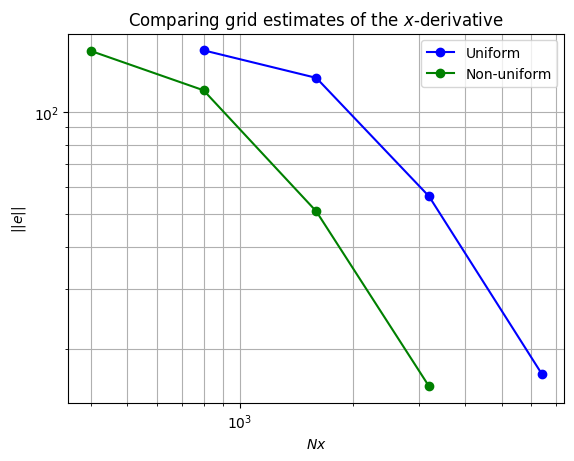

In [82]:
#plt.loglog(Nx_values_nonuniform,10*np.array(Nx_values_nonuniform), 'k--', label=r"$O(\Delta x)$")
plt.loglog(Nx_values_uniform,uniform_errors,'o-',color="blue", label=r"Uniform")
plt.loglog(Nx_values_nonuniform,nonuniform_errors,'o-',color="green", label=r"Non-uniform")
plt.title("Comparing grid estimates of the $x$-derivative")
plt.xlabel(r'$Nx$')
plt.ylabel(r'$||e||$')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

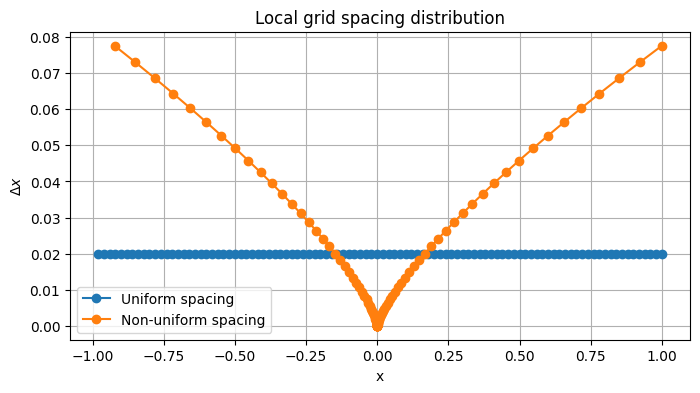

In [108]:
Nx = 100
xi = np.linspace(-1, 1, Nx+1)   # uniform computational grid
x_uniform = xi
x_nonuniform = np.sign(xi) * np.abs(xi)**4   # mapped physical grid

plt.figure(figsize=(8,4))

plt.plot(x_uniform[1:], np.diff(x_uniform), 'o-', label="Uniform spacing")
plt.plot(x_nonuniform[1:], np.diff(x_nonuniform), 'o-', label="Non-uniform spacing")

plt.xlabel("x")
plt.ylabel(r"$\Delta x$")
plt.title("Local grid spacing distribution")
plt.grid(True)
plt.legend()
plt.show()